### LAB ASSIGNMENT 2: DECISION TREE 

Problem Statement

Using the **Decision Tree algorithm**, predict which drug — among `DrugA`, `DrugB`, `DrugC`, `DrugX`, and `DrugY` — should be prescribed to a patient based on their health profile.

#### Importing Libraries and Loading dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score

In [2]:
# Loading the dataset

df = pd.read_csv("Datasets/drug.csv")

#### Exploratory Data Analysis (EDA)

In [3]:
# Preview the data

df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [4]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns")

The dataset has 200 rows and 6 columns


In [5]:
# Summary of dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [6]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [7]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

#### Data Preprocessing

In [8]:
df_encoded = df.copy()

In [9]:
# Encoding each categorical feature
le_sex = LabelEncoder()
df_encoded['Sex'] = le_sex.fit_transform(df_encoded['Sex'])           

le_bp = LabelEncoder()
df_encoded['BP'] = le_bp.fit_transform(df_encoded['BP'])            

le_chol = LabelEncoder()
df_encoded['Cholesterol'] = le_chol.fit_transform(df_encoded['Cholesterol'])  

In [10]:
df_encoded.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,drugY
1,47,1,1,0,13.093,drugC
2,47,1,1,0,10.114,drugC
3,28,0,2,0,7.798,drugX
4,61,0,1,0,18.043,drugY


#### Model Training

In [11]:
# Features and target
X = df_encoded.drop('Drug', axis=1)
y = df_encoded['Drug']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (160, 5)
Test set size: (40, 5)


In [14]:
# Initializing the model
model = DecisionTreeClassifier(random_state=42)

In [15]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

#### Model Predictions and Evaluation

In [16]:
# Use the trained model to predict drug classes for the unseen test data
y_pred = model.predict(X_test)

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         6
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        11
       drugY       1.00      1.00      1.00        15

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [18]:
print("Macro Precision:", precision_score(y_test, y_pred, average='macro'))
print("Macro Recall:", recall_score(y_test, y_pred, average='macro'))
print("Macro F1 Score:", f1_score(y_test, y_pred, average='macro'))

Macro Precision: 1.0
Macro Recall: 1.0
Macro F1 Score: 1.0


In [19]:
print("Tree depth:", model.get_depth())
print("Number of leaves:", model.get_n_leaves())

Tree depth: 4
Number of leaves: 6


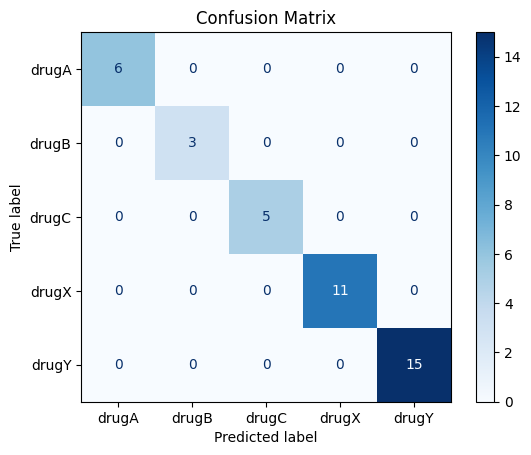

In [20]:
# Compute and plot confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### Tree Visualization

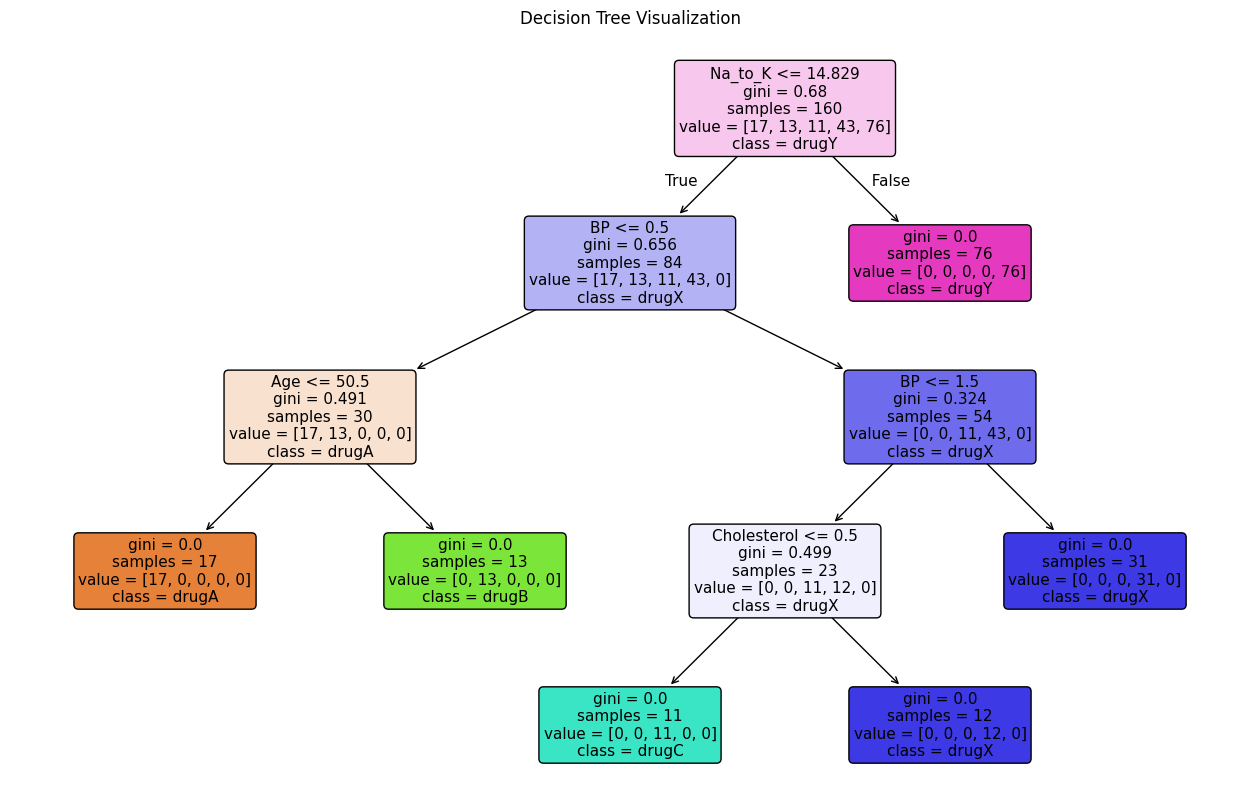

In [21]:
plt.figure(figsize=(16, 10))
plot_tree(model, 
          feature_names=X.columns, 
          class_names=sorted(y.unique()), 
          filled=True, 
          rounded=True,
          fontsize=11)
plt.title("Decision Tree Visualization")
plt.show()

In [22]:
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

       Feature  Importance
4      Na_to_K    0.493261
2           BP    0.265658
0          Age    0.135510
3  Cholesterol    0.105571
1          Sex    0.000000


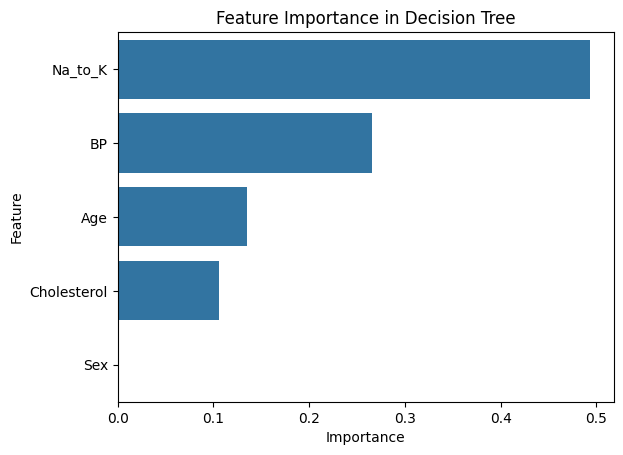

In [23]:
# Visualize feature importance
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title("Feature Importance in Decision Tree")
plt.show()

##### Final Observations

- The Decision Tree model achieved **100% accuracy**, indicating that the dataset is clean and the classes are easily separable.
- **Na_to_K** and **BP** were the most significant features, as they appeared in early splits of the tree.
- **Sex** was not used by the model, suggesting it had no predictive power in this context.
- Tree depth: 4 — shallow enough to avoid overfitting.
- Total leaves: 6 — roughly equal to the number of unique drug classes (5), indicating clean decision paths.